In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook

In [5]:
output_notebook()

Loading BokehJS ...

In [6]:
df = pd.read_csv('techstore_chile_2024.csv')

In [7]:
df

,mes,categoria,unidades,precio_unitario,ingresos,nps,devueltos
0,1,Accesorios,639,26.6,16997.4,79,6
1,1,Accesorios,603,27.4,16522.2,83,4
2,1,Accesorios,617,27.1,16720.7,88,3
3,1,Accesorios,670,25.8,17286.0,90,5
4,1,Accesorios,586,24.6,14415.6,84,1
...,...,...,...,...,...,...,...
295,6,Monitores,96,526.1,50505.6,67,7
296,6,Monitores,124,509.5,63178.0,76,8
297,6,Monitores,101,529.6,53489.6,73,8
298,6,Monitores,132,501.4,66184.8,77,8


In [16]:
df.dtypes

mes                  int64
categoria           object
unidades             int64
precio_unitario    float64
ingresos           float64
nps                  int64
devueltos            int64
dtype: object

In [13]:
df.isnull().sum()

mes                0
categoria          0
unidades           0
precio_unitario    0
ingresos           0
nps                0
devueltos          0
dtype: int64

<Axes: >

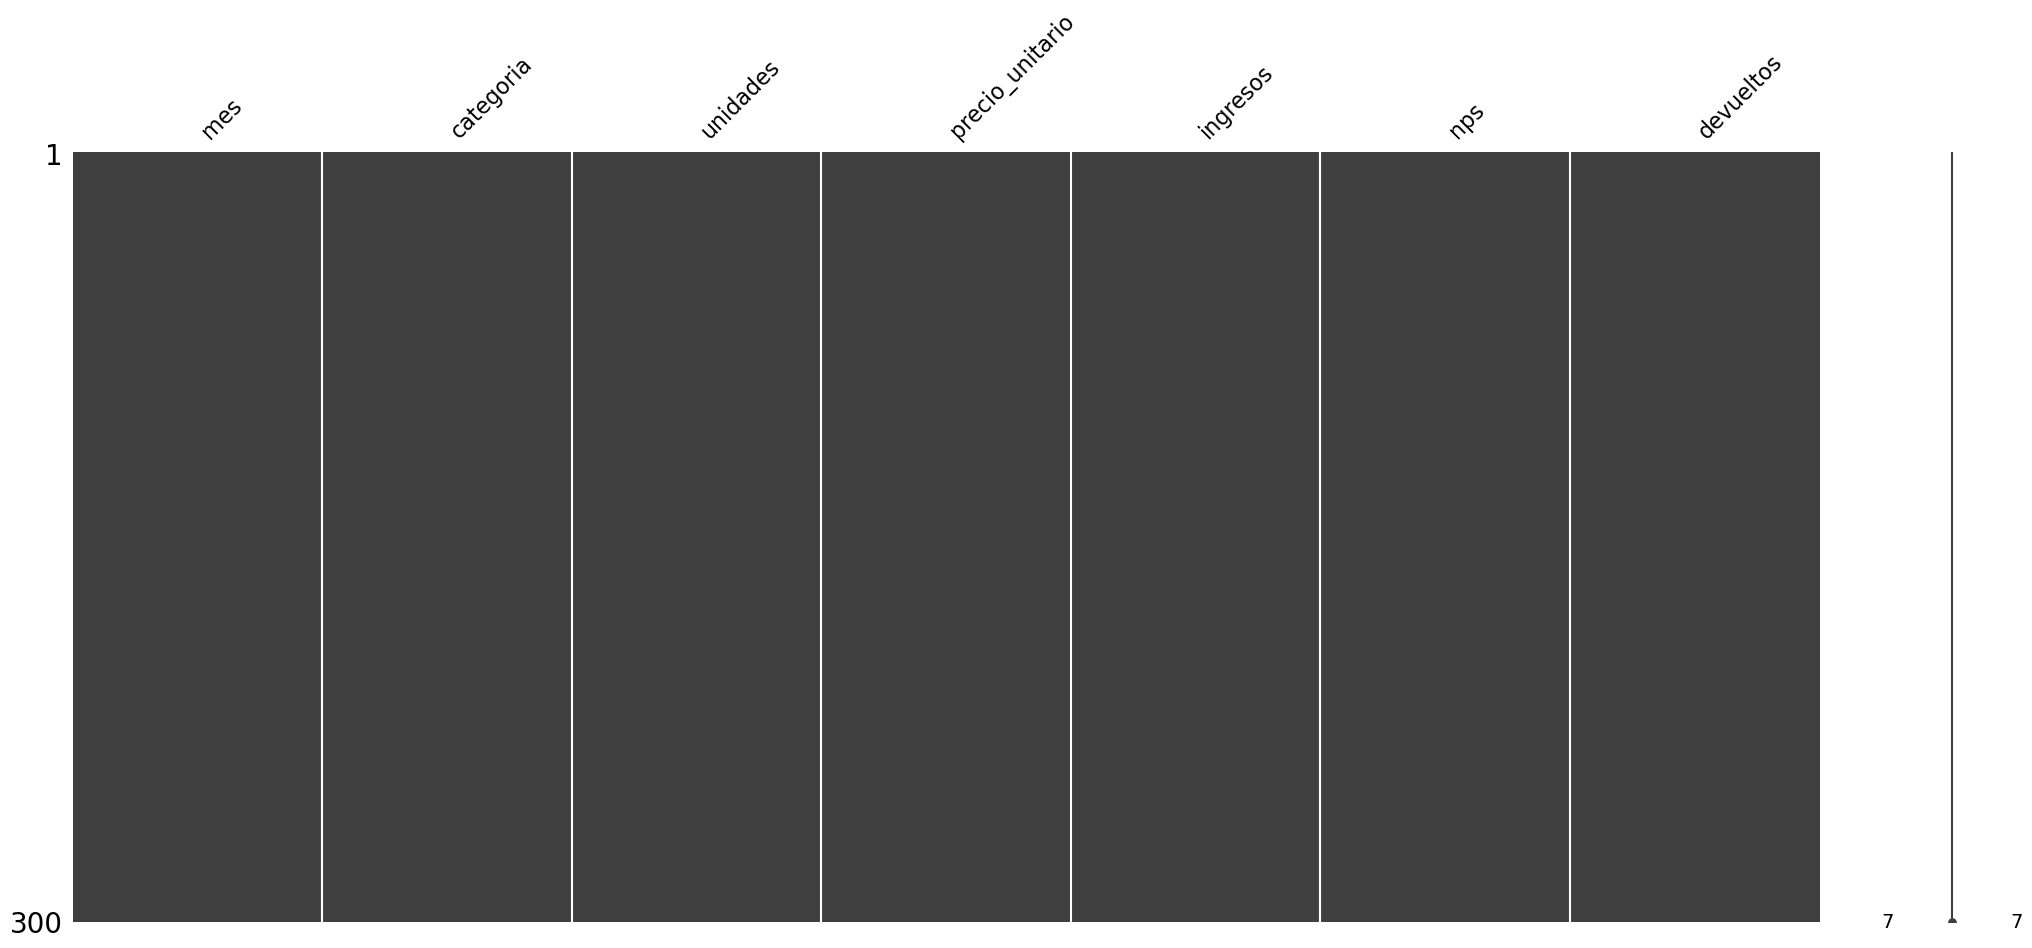

In [15]:
import missingno as msno
msno.matrix(df)

El dataset posee 300 filas y 7 columnas según el df.describe dado.
Según la suma de los isnull y la visualización de matrix, no hay nulos en el dataset.
Los tipos de datos presentes en el dataset son tipos enteros (int64), decimales (float64) y objetos (objets)

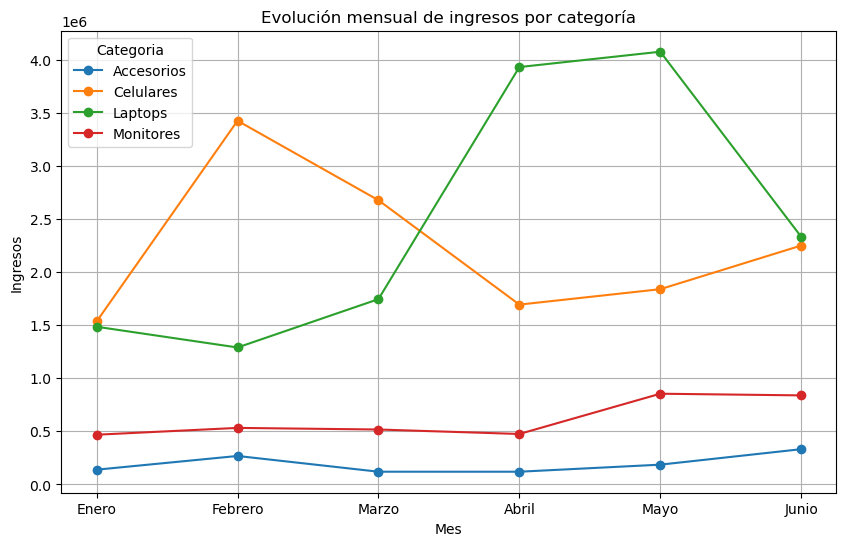

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
ingresos_cat = df.groupby(['mes', 'categoria'])['ingresos'].sum().unstack()

ingresos_cat.plot(kind='line', marker='o', ax=ax)
ax.set_title("Evolución mensual de ingresos por categoría")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos")
ax.set_xticks(range(1, 7))
ax.set_xticklabels(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio'])
ax.grid(True)
plt.legend(title='Categoria')
plt.show()

C:\Users\thewe\AppData\Local\Temp\ipykernel_6376\3790622696.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio'])


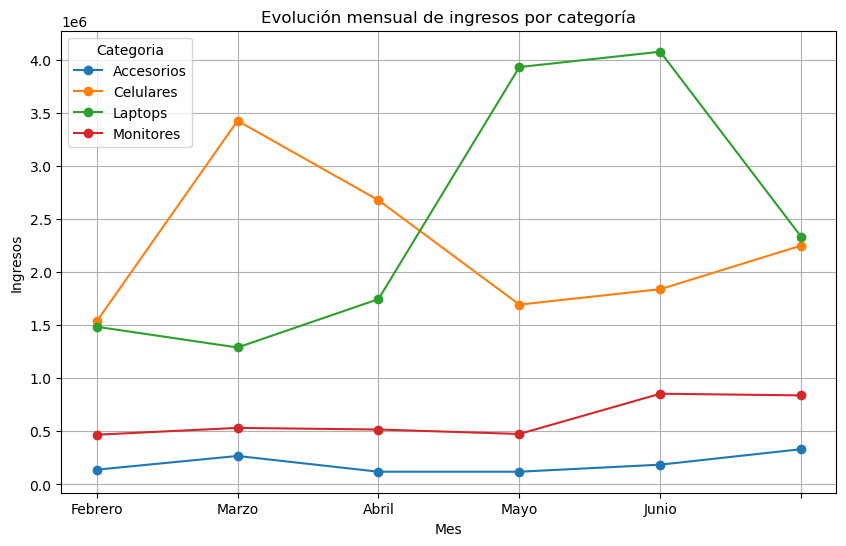

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ingresos_cat = df.groupby(['mes', 'categoria'])['ingresos'].sum().unstack()

ingresos_cat.plot(kind='line', marker='o', ax=ax)
ax.set_title("Evolución mensual de ingresos por categoría")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos")
ax.set_xticklabels(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio'])
ax.grid(True)
plt.legend(title='Categoria')
plt.show()

In [69]:
for i, cat in enumerate(df['categoria'].unique()):
    subset = df[df['categoria'] == cat].sort_values('mes')
    ax.plot(subset['mes'], subset['ingresos'], color=colores[i],
        linewidth=2.5,
        marker='o',
        markersize=7,
        label=cat
    )

ValueError: 0 is not a valid value for color

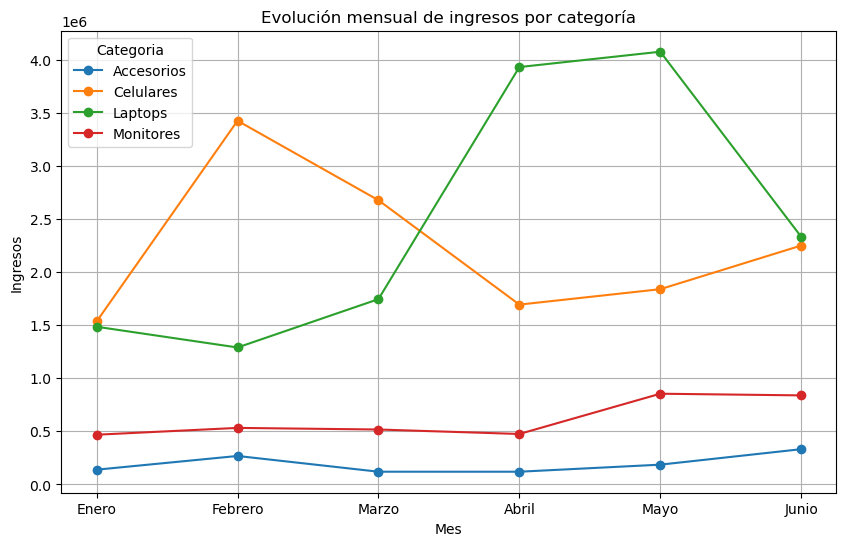

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
ingresos_cat = df.groupby(['mes', 'categoria'])['ingresos'].sum().unstack()

ingresos_cat.plot(kind='line', marker='o', ax=ax)
ax.set_title("Evolución mensual de ingresos por categoría")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos")
ax.set_xticks(range(1, 7))
ax.set_xticklabels(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio'])
ax.grid(True, alpha=1.0)
plt.legend(title='Categoria')
plt.show()

1) Podemos observar que hay un crecimiento relativo cuesta arriba, debido a multiples factores como pueden ser marketing, etc.
2) En mi caso quité set.sticksx y pasó que el gráfico se descuadra totalmente, dando un gráfico fuera de lugar e incorrecto
3) Tal vez de mi punto de vista las lineas de las cuadriculas se vean más opacas en relación a si se aumenta más el alpha. (Siendo más "fuerte")

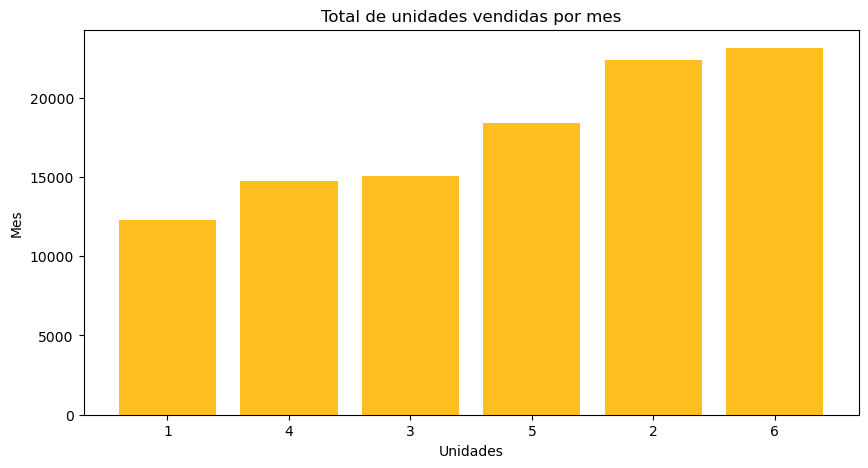

In [43]:
#Ejercicio 2
fig, ax = plt.subplots(figsize=(10, 5))
unidades_mes = df.groupby('mes')['unidades'].sum().sort_values(ascending=True)
colores = ['#FFBF20' if val > 1400 else 'amarillo' for val in unidades_mes.values]
bars = ax.bar(unidades_mes.index.astype(str), unidades_mes.values, color=colores)
ax.set_title("Total de unidades vendidas por mes")
ax.set_xlabel("Unidades")
ax.set_ylabel("Mes")

plt.show()

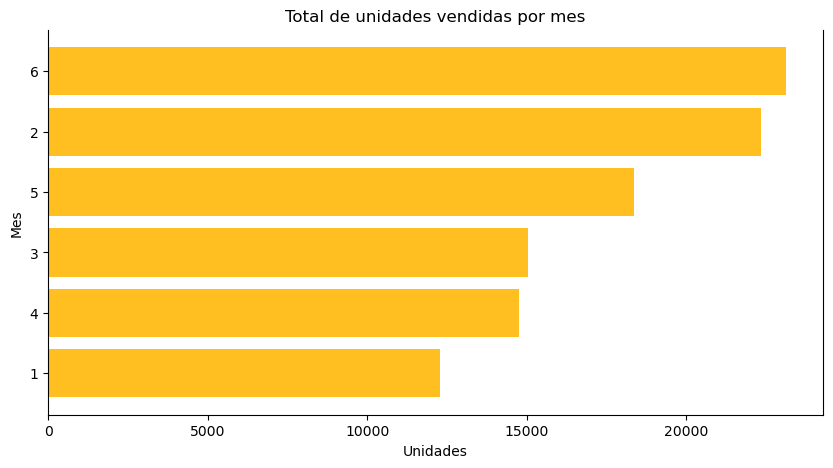

In [54]:
#Ejercicio 2
fig, ax = plt.subplots(figsize=(10, 5))
unidades_mes = df.groupby('mes')['unidades'].sum().sort_values(ascending=True)
colores = ['#FFBF20' if val > 1400 else 'amarillo' for val in unidades_mes.values]
bars = ax.barh(unidades_mes.index.astype(str), unidades_mes.values, color=colores)
ax.set_title("Total de unidades vendidas por mes")
ax.set_xlabel("Unidades")
ax.set_ylabel("Mes")
ax.spines['top'].set_visible(False)
plt.show()

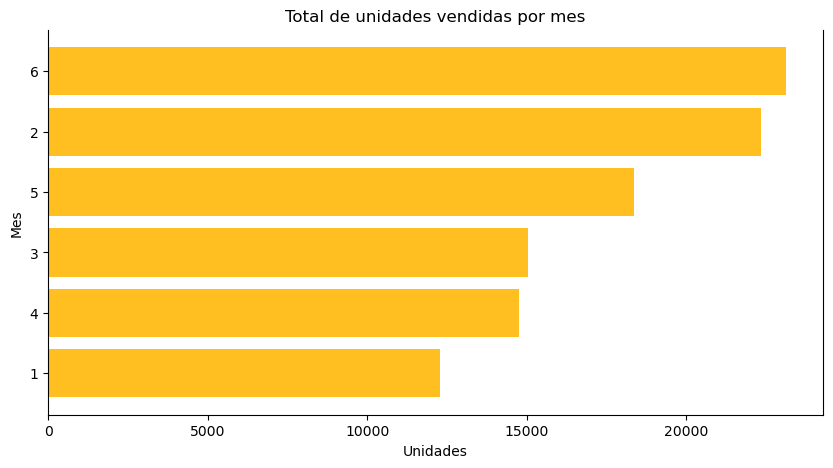

In [58]:
#Ejercicio 2
#Traté de implementar la lógica en colores, pero no me dio no sé porqué, disculpe de antemano.
fig, ax = plt.subplots(figsize=(10, 5))
unidades_mes = df.groupby('mes')['unidades'].sum().sort_values(ascending=True)
colores = ['#FFBF20' if val > 1400 else 'green' for val in unidades_mes.values]
bars = ax.barh(unidades_mes.index.astype(str), unidades_mes.values, color=colores)
ax.set_title("Total de unidades vendidas por mes")
ax.set_xlabel("Unidades")
ax.set_ylabel("Mes")
ax.spines['top'].set_visible(False)
plt.show()

1. Generan gráficos de barra vertical como horizontal como tal, dependiendo el caso que se requiera visualizar es mejor el vertical
2. Creo que ayuda visualmente a que le gráfico se vea más "ordenado" dependiendo del punto de vista de la persona.

In [ ]:
## Scatter plot
#plt.figure()
#plt.scatter(df["cantidad"], df["monto_bruto"])
#plt.xlabel("Cantidad vendida")
#plt.ylabel("Monto bruto")
#plt.title("Cantidad vs Monto de Ventas")
#plt.tight_layout()
#plt.show()
#----------
#plt.figure()
#for categoria in df["categoria"].unique():
#subset = df[df["categoria"] == categoria]
#plt.scatter(subset["cantidad"], subset["monto_bruto"], label=categoria)
#plt.xlabel("Cantidad vendida")
#plt.ylabel("Monto bruto")
#plt.title("Cantidad vs Ventas por Categoría")
#plt.legend()
#plt.tight_layout()
#plt.show()

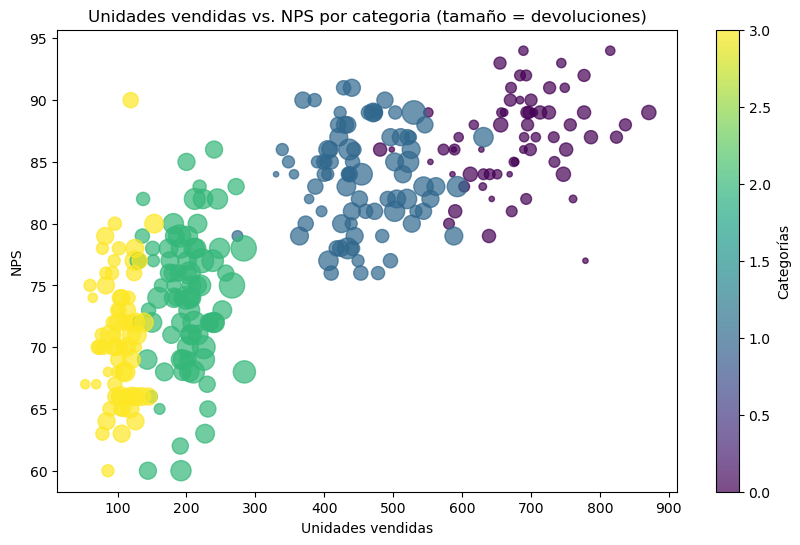

In [61]:
#Ejercicio 3.
fig, ax = plt.subplots(figsize=(10, 6))

categorias = df['categoria'].astype('category')
colores = categorias.cat.codes

scatter = ax.scatter(
    x=df['unidades'],
    y=df['nps'], 
    s=df['devueltos'] * 15,
    c=colores, 
    cmap='viridis', 
    alpha=0.7
)

ax.set_title("Unidades vendidas vs. NPS por categoria (tamaño = devoluciones)")
ax.set_xlabel("Unidades vendidas")
ax.set_ylabel("NPS")

cbar = plt.colorbar(scatter)
cbar.set_label('Categorías')

plt.show()

3. Se podría decir que si en cuanto a las unidades vendidas en relación a las categorías de los productos
4. Se multiplica por 20 para que así sea más visualmente aceptable, si no pusieramos el por 20, no se podría ver prácticamente, ya que estaría a una microescala muy pequeña.
5. El eje x representa en cuestión las unidades vendidas, Y la satisfacción en la escala NPS y el color representa la categoría del producto.

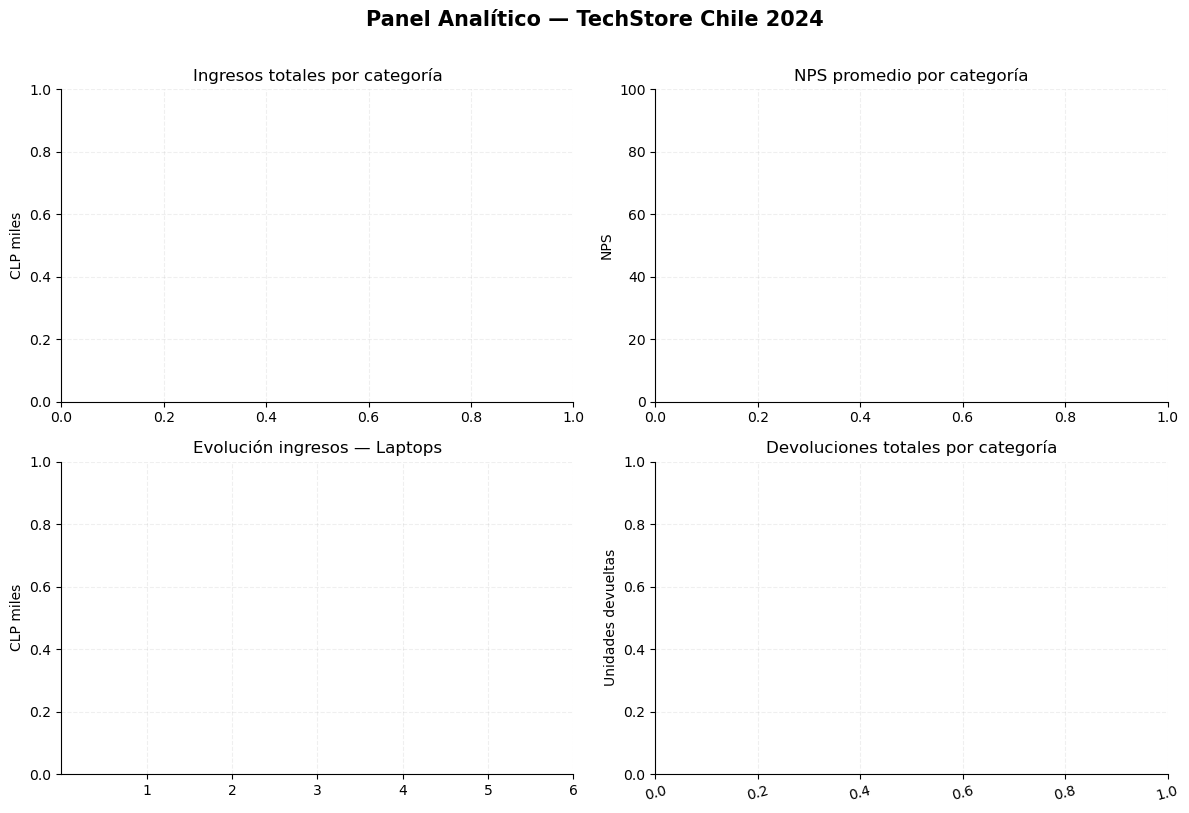

In [62]:
#Ejercicio 4 
ingresos_cat = df.groupby('categoria')['ingresos'].sum().sort_values(ascending=False)
nps_cat = df.groupby('categoria')['nps'].mean()
dev_cat = df.groupby('categoria')['devueltos'].sum()
laptops = df[df['categoria'] == 'Laptops'].sort_values('mes')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Panel Analítico — TechStore Chile 2024', fontsize=15, fontweight='bold',
y=1.01)
# [0,0] Ingresos totales por categoría
# genere un grafico de barras con los ingresos totales por categoría.
axes[0,0].set_title('Ingresos totales por categoría')
axes[0,0].set_ylabel('CLP miles')
# [0,1] NPS promedio por categoría
# genere un grafico de barras
axes[0,1].set_title('NPS promedio por categoría')
axes[0,1].set_ylabel('NPS')
axes[0,1].set_ylim(0, 100)
# [1,0] Evolución de Laptops
# grafico de evolución de ingresos de laptops
axes[1,0].set_title('Evolución ingresos — Laptops')
axes[1,0].set_xticks(range(1, 7))
axes[1,0].set_ylabel('CLP miles')
# [1,1] Devoluciones por categoría
# grafico de barras
axes[1,1].set_title('Devoluciones totales por categoría')
axes[1,1].set_ylabel('Unidades devueltas')
axes[1,1].tick_params(axis='x', rotation=15)
for ax in axes.flat:
 ax.grid(True, alpha=0.2, linestyle='--')
 ax.spines['top'].set_visible(False)
 ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


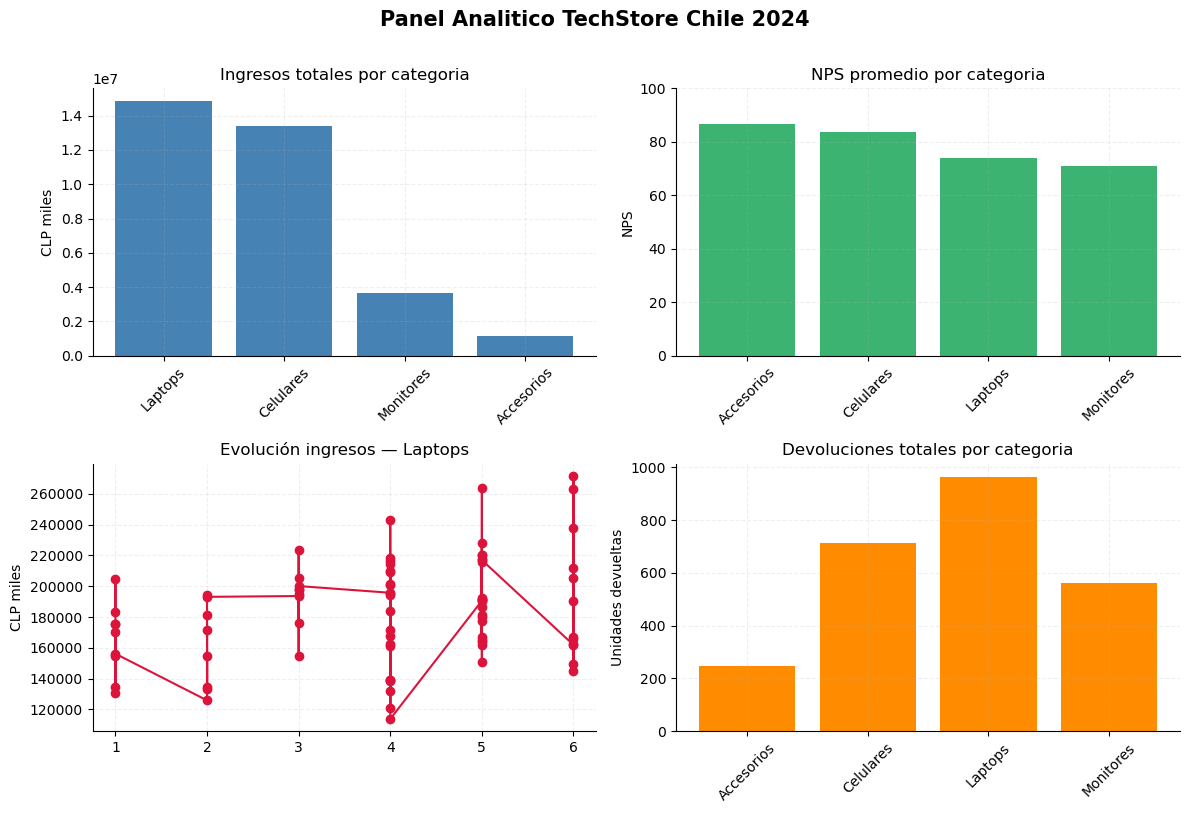

In [72]:
ingresos_cat = df.groupby('categoria')['ingresos'].sum().sort_values(ascending=False)
nps_cat = df.groupby('categoria')['nps'].mean()
dev_cat = df.groupby('categoria')['devueltos'].sum()
laptops = df[df['categoria'] == 'Laptops'].sort_values('mes')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Panel Analitico TechStore Chile 2024', fontsize=15, fontweight='bold', y=1.01)

axes[0,0].bar(ingresos_cat.index, ingresos_cat.values, color='steelblue')
axes[0,0].set_title('Ingresos totales por categoria')
axes[0,0].set_ylabel('CLP miles')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].bar(nps_cat.index, nps_cat.values, color='mediumseagreen')
axes[0,1].set_title('NPS promedio por categoria')
axes[0,1].set_ylabel('NPS')
axes[0,1].set_ylim(0, 100)
axes[0,1].tick_params(axis='x', rotation=45)

axes[1,0].plot(laptops['mes'], laptops['ingresos'], marker='o', color='crimson')
axes[1,0].set_title('Evolución ingresos — Laptops')
axes[1,0].set_xticks(range(1, 7))
axes[1,0].set_ylabel('CLP miles')

axes[1,1].bar(dev_cat.index, dev_cat.values, color='darkorange')
axes[1,1].set_title('Devoluciones totales por categoria')
axes[1,1].set_ylabel('Unidades devueltas')
axes[1,1].tick_params(axis='x', rotation=45)

for ax in axes.flat:
    ax.grid(True, alpha=0.2, linestyle='--') 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

1. La conclusión que se puede extraer es que el volumen de ventas podría traer consigo misma algunos problemas a posterior
2. Uno es más general y otro más especifico para cada gráfico, siendo ambos útiles dependiendo el caso.
3. Ayuda a "aplanar" por así decirlo el código, siguiendo en una dimensión siendo más fácil de iterar, evitando algunos errores en cuanto a los gráficos.

In [71]:
#Ejercicio 5.
# SUGERENCIA = Preparar datos agregados
ingresos_mes = df.groupby('mes')['ingresos'].sum().reset_index()
ingresos_mes['mes_label'] = meses_labels
ingresos_mes['ingresos_fmt'] = ingresos_mes['ingresos'].map(lambda x: f'${x:,.0f}K')
source = ColumnDataSource(ingresos_mes)
hover = HoverTool(tooltips=[
 ('Mes', '@mes_label'),
 ('Ingresos', '@ingresos_fmt'),
])
# Genere aqui la figura de Bokeh “recuerde que la sintaxis es p = figure(opciones) “
# agregamos el grafico de barras
p.vbar(
 x='mes_label',
 top='ingresos',
 source=source,
 width=0.65,
 color='#0D9488',
 line_color='#065F52',
 alpha=0.85,
)
p.xgrid.grid_line_color = None
p.ygrid.grid_line_alpha = 0.3
p.yaxis.axis_label = 'Ingresos (CLP miles)'
p.xaxis.axis_label = 'Mes'
p.title.text_font_size = '13px'
show(p)

NameError: name 'meses_labels' is not defined

In [ ]:
#Utilizo el código de ejemplo para poder reeplicarlo/editarlo con Bokeh, dando lo siguiente.

In [80]:
ingresos_mes = df.groupby('mes').agg({'ingresos': 'sum', 'unidades': 'sum'}).reset_index()
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
ingresos_mes['mes_label'] = ingresos_mes['mes'].apply(lambda x: meses_labels[x-1]) 
ingresos_mes['ingresos_fmt'] = ingresos_mes['ingresos'].map(lambda x: f'${x:,.0f} K')

source = ColumnDataSource(ingresos_mes)

hover = HoverTool(tooltips=[ 
    ('Mes', '@mes_label'),
    ('Ingresos', '@ingresos_fmt'),
    ('Unidades vendidas', '@unidades')
])

p = figure(x_range=ingresos_mes['mes_label'].tolist(), 
           title="Ingresos y Unidades por Mes", 
           tools=[hover, 'pan,wheel_zoom,box_zoom,reset'])

p.vbar(
    x='mes_label', 
    top='ingresos', 
    source=source, 
    width=0.65, 
    color='#0D9488', 
    line_color='#065F52', 
    alpha=0.85 
)

p.xgrid.grid_line_color = None
p.ygrid.grid_line_alpha = 0.3
p.yaxis.axis_label = 'Ingresos (CLP miles)'
p.xaxis.axis_label = 'Mes'
p.title.text_font_size = '13px'

show(p)

1. La ventaja que tiene Bokeh en cuanto a este gráfico es que puede mostrar la información de la barra de cada mes, siendo más objetivo y fácil de visualizar para personas que requieren saber de manera más explícita el resultado. Con info. como mes, ingresos y unidades vendidas de manera más  explícita a simple vista
2. Según lo que investigué, el símbolo como tal de "@" Bokeh busca en las columnas con alguna clave en su diccionario en conjunto, que le pasamos a la "ColumnDataResource".